In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

In [3]:
 train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


# *descriptive stats*

In [4]:
train.describe(include='all')

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
count,198000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,52577,52577,52577,198000,197999,198000.000000
unique,197996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,8,5,2,197842,NaN
top,2022-05-06 20:47:06.726636+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,none,none,False,Exactly..,NaN
freq,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39682,38249,36161,195257,8,NaN
mean,NaN,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,NaN,NaN,NaN,NaN,NaN,0.793965
std,NaN,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,NaN,NaN,NaN,NaN,NaN,0.979808
min,NaN,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,NaN,NaN,NaN,NaN,NaN,2.000000


In [5]:
train.shape, test.shape

((198000, 15), (102000, 14))

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


# *handling missing values*

In [7]:
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100
missing_df = pd.DataFrame({"Missing": missing, "%": missing_percent})

missing_df[missing_df["Missing"] > 0]

,Missing,%
race,145423,73.445960
religion,145423,73.445960
gender,145423,73.445960
comment,1,0.000505


In [8]:
train['label'].value_counts(normalize=False)

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [9]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [10]:
# Select numerical columns
num_cols = train.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = pd.DataFrame()

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    outlier_summary.loc[col, 'Outlier Count'] = len(outliers)
    outlier_summary.loc[col, 'Outlier Percentage'] = (len(outliers) / len(train)) * 100
    outlier_summary.loc[col, 'Lower Bound'] = lower
    outlier_summary.loc[col, 'Upper Bound'] = upper

print(outlier_summary.sort_values('Outlier Count', ascending=False))

            Outlier Count  Outlier Percentage  Lower Bound  Upper Bound
emoticon_1        28922.0           14.607071          0.0          0.0
upvote            17304.0            8.739394         -4.5          7.5
emoticon_3        17165.0            8.669192          0.0          0.0
downvote          15173.0            7.663131         -1.5          2.5
emoticon_2         8109.0            4.095455          0.0          0.0
post_id            4823.0            2.435859        -10.5        121.5
if_2               3930.0            1.984848         -5.0         19.0
if_1                 85.0            0.042929         -6.0         10.0
label                 0.0            0.000000         -3.0          5.0


In [11]:
from scipy import stats

z_scores = pd.DataFrame()

for col in num_cols:
    z = np.abs(stats.zscore(train[col].dropna()))
    outlier_count = (z > 3).sum()
    z_scores.loc[col, 'Outlier Count'] = outlier_count
    z_scores.loc[col, 'Outlier Percentage'] = (outlier_count / len(train)) * 100

print(z_scores.sort_values('Outlier Count', ascending=False))

            Outlier Count  Outlier Percentage
emoticon_2         8109.0            4.095455
emoticon_3         4148.0            2.094949
if_2               3534.0            1.784848
upvote             3508.0            1.771717
downvote           3488.0            1.761616
emoticon_1         3078.0            1.554545
if_1                 51.0            0.025758
post_id               0.0            0.000000
label                 0.0            0.000000


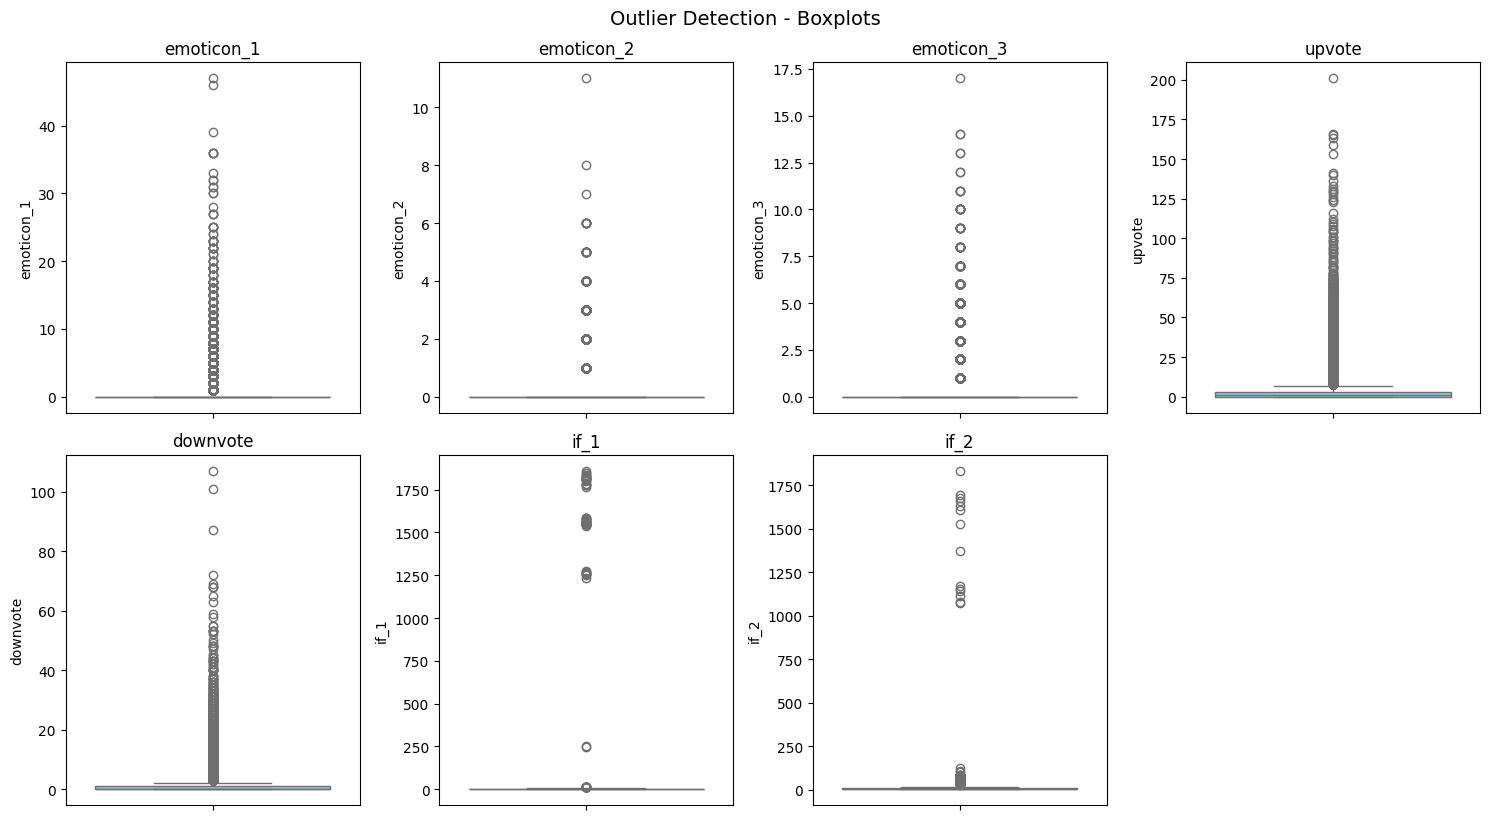

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Based on your dataset's numerical columns
num_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 
            'upvote', 'downvote', 'if_1', 'if_2']

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=train[col], color='skyblue')
    plt.title(f'{col}')
    plt.tight_layout()

plt.suptitle('Outlier Detection - Boxplots', y=1.02, fontsize=14)
plt.show()

In [13]:
cat_cols = ['race', 'religion', 'gender']
num_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3',
            'upvote', 'downvote', 'if_1', 'if_2']

In [14]:
train = train.drop(columns=['post_id', 'created_date'])
train['comment'] = train['comment'].fillna('')

# handling the missing values of categorical and numerical fetures
**So OHE would create a dedicated race_Unknown, religion_Unknown, gender_Unknown column that is 1 for 73% of rows and 0 for the rest. That column carries almost no useful information and just adds noise.so did i use ordinal encoder**

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder())
])
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

In [16]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline, num_cols)
], remainder='passthrough')

In [17]:
transformed = preprocessor.fit_transform(train)
 
transformed_cols = cat_cols + num_cols + ['disability', 'comment', 'label']
train_processed = pd.DataFrame(transformed, columns=transformed_cols)
 
print("Shape:", train_processed.shape)
print("Missing:\n", train_processed.isnull().sum())


Shape: (198000, 13)
Missing:
 race          0
religion      0
gender        0
emoticon_1    0
emoticon_2    0
emoticon_3    0
upvote        0
downvote      0
if_1          0
if_2          0
disability    0
comment       0
label         0
dtype: int64


In [18]:
train_processed.head()

,race,religion,gender,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,10.0,False,She might be a bright spot for a party keou on...,2
1,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,4.0,False,"Under Alaska law, a non-tribal member is not b...",0
2,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.0,False,in the future please spare me your strawman dr...,2
3,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,10.0,False,"PS: That should have been ""rot"" instead of ""co...",2
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,False,"Today, the confederate flag...tomorrow, the na...",2


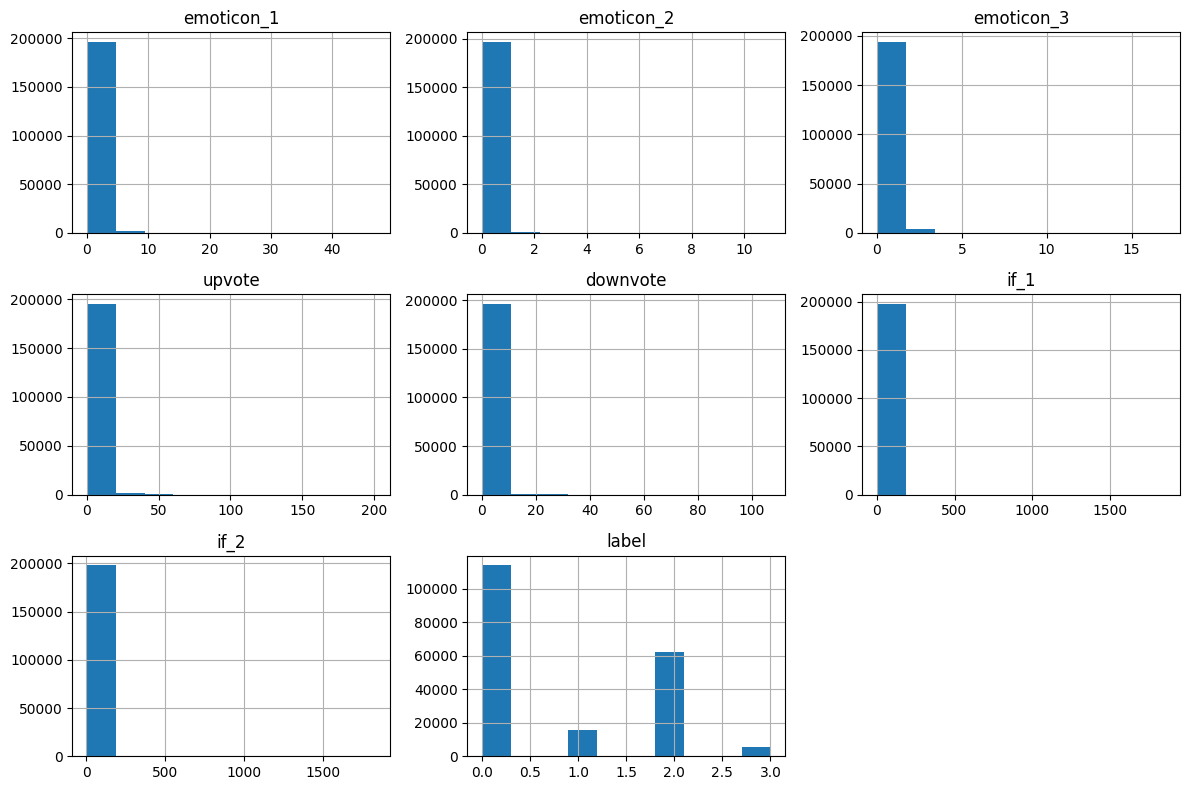

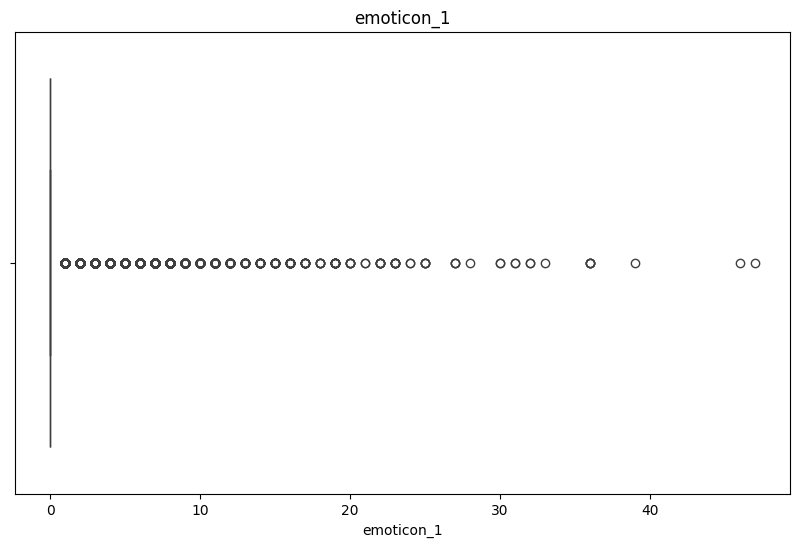

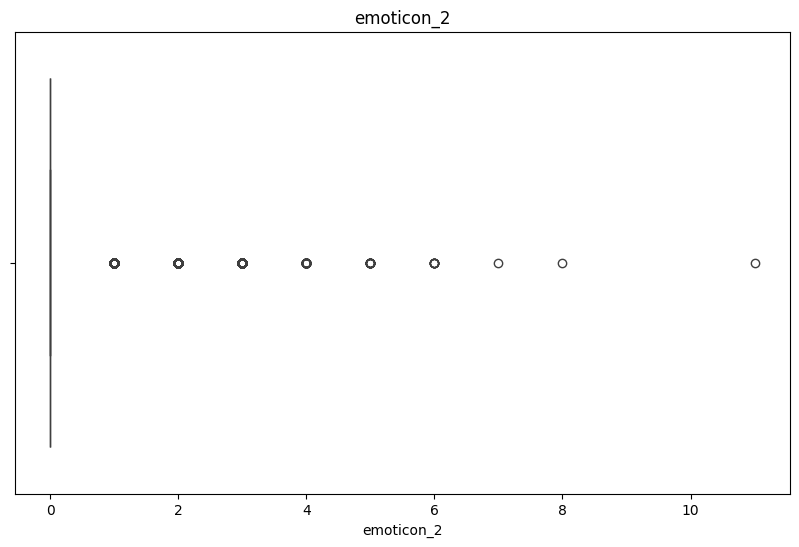

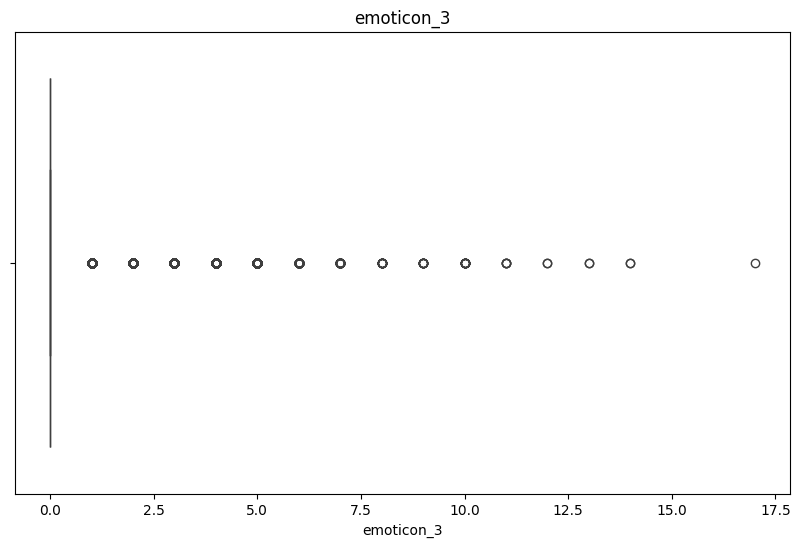

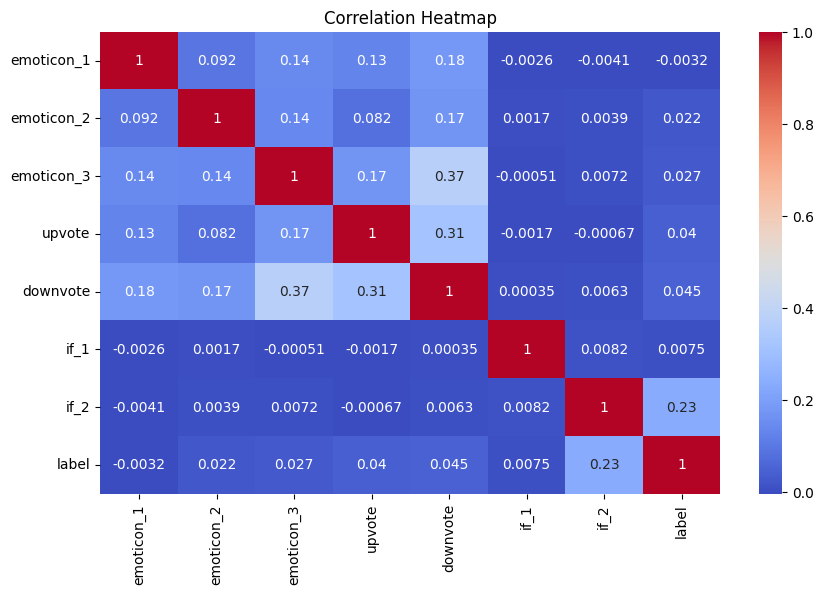

In [19]:
# Histogram for all numerical columns
num_cols = train.select_dtypes(include=['int64', 'float64']).columns

train[num_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Boxplot for numerical columns
for col in num_cols[:3]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
# Fix dtypes - convert everything except comment to numeric
cols_to_convert = ['race', 'religion', 'gender', 'emoticon_1', 'emoticon_2', 
                   'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 
                   'disability', 'label']

train_processed[cols_to_convert] = train_processed[cols_to_convert].astype(float).astype(int)

# Verify
print(train_processed.dtypes)
train_processed.head()

race           int64
religion       int64
gender         int64
emoticon_1     int64
emoticon_2     int64
emoticon_3     int64
upvote         int64
downvote       int64
if_1           int64
if_2           int64
disability     int64
comment       object
label          int64
dtype: object


,race,religion,gender,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label
0,0,0,0,0,0,0,0,1,0,10,0,She might be a bright spot for a party keou on...,2
1,0,0,0,0,0,0,6,0,0,4,0,"Under Alaska law, a non-tribal member is not b...",0
2,0,0,0,0,1,1,0,0,0,10,0,in the future please spare me your strawman dr...,2
3,0,0,0,0,0,0,5,0,0,10,0,"PS: That should have been ""rot"" instead of ""co...",2
4,0,0,0,0,0,0,0,0,0,10,0,"Today, the confederate flag...tomorrow, the na...",2


In [21]:
train_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   race        198000 non-null  int64 
 1   religion    198000 non-null  int64 
 2   gender      198000 non-null  int64 
 3   emoticon_1  198000 non-null  int64 
 4   emoticon_2  198000 non-null  int64 
 5   emoticon_3  198000 non-null  int64 
 6   upvote      198000 non-null  int64 
 7   downvote    198000 non-null  int64 
 8   if_1        198000 non-null  int64 
 9   if_2        198000 non-null  int64 
 10  disability  198000 non-null  int64 
 11  comment     198000 non-null  object
 12  label       198000 non-null  int64 
dtypes: int64(12), object(1)
memory usage: 19.6+ MB


In [22]:
for col in ['race', 'religion', 'gender']:
    print(f"\n{col}: {train_processed[col].unique()}")


race: [0 4 6 5 1 2 3]

religion: [0 3 6 7 5 1 8 4 2]

gender: [0 3 2 1 5 4]


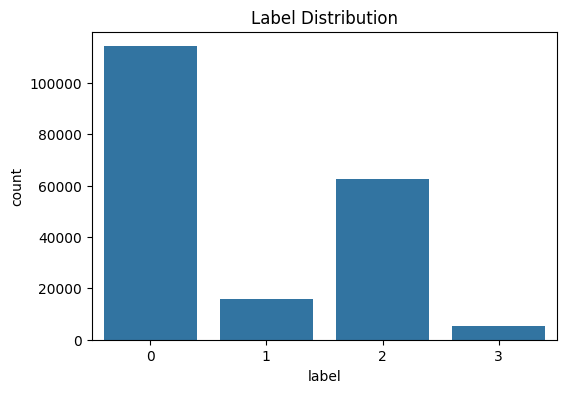

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train)
plt.title('Label Distribution')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train_processed.drop(columns=['label', 'comment'])
y = train_processed['label']

In [25]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [26]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nClass distribution in y_train:\n", y_train.value_counts())

X_train shape: (158400, 11)
X_test shape: (39600, 11)
y_train shape: (158400,)
y_test shape: (39600,)

Class distribution in y_train:
 label
0    91338
2    49952
1    12735
3     4375
Name: count, dtype: int64


In [27]:

cat_cols = ['emoticon_1','emoticon_2','emoticon_3','race','religion','gender','disability']

for col in cat_cols:
    print(f"\n{col} vs label")
    print(pd.crosstab(train[col], train['label'], normalize='index'))


emoticon_1 vs label
label              0         1         2         3
emoticon_1                                        
0           0.578674  0.080738  0.312891  0.027697
1           0.556127  0.080360  0.336199  0.027314
2           0.563201  0.076392  0.336092  0.024315
3           0.569433  0.071550  0.325148  0.033870
4           0.593725  0.078037  0.304103  0.024135
5           0.594044  0.078370  0.300940  0.026646
6           0.596257  0.080214  0.288770  0.034759
7           0.640000  0.075556  0.266667  0.017778
8           0.635802  0.061728  0.259259  0.043210
9           0.705882  0.088235  0.186275  0.019608
10          0.695652  0.057971  0.217391  0.028986
11          0.676471  0.073529  0.220588  0.029412
12          0.675000  0.100000  0.225000  0.000000
13          0.740741  0.074074  0.185185  0.000000
14          0.631579  0.000000  0.263158  0.105263
15          0.700000  0.050000  0.200000  0.050000
16          0.600000  0.000000  0.400000  0.000000
17        

In [28]:
train['comm_len'] = train['comment'].str.len()

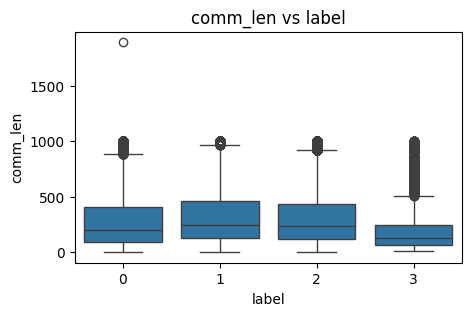

In [29]:
plt.figure(figsize=(5,3))
sns.boxplot(x = 'label', y = 'comm_len', data = train)
plt.title('comm_len vs label')
plt.show()

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,  # top 10000 words
    ngram_range=(1, 2),  # unigrams and bigrams
    min_df=5,            # ignore words appearing in less than 5 docs
    max_df=0.95          # ignore words appearing in more than 95% docs
)

X_tfidf = tfidf.fit_transform(train_processed['comment'])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (198000, 10000)


# comaprison of Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse as sp



X_comment_train = tfidf.fit_transform(train_processed.loc[X_train.index, 'comment'])
X_comment_test  = tfidf.transform(train_processed.loc[X_test.index, 'comment'])

# Combine TF-IDF + numerical features
X_train_full = sp.hstack([X_comment_train, sp.csr_matrix(X_train.values)])
X_test_full  = sp.hstack([X_comment_test,  sp.csr_matrix(X_test.values)])

# Models
models = {
    "Logistic": LogisticRegression(max_iter=2000, solver='saga', class_weight='balanced'),
    "RandomForest":RandomForestClassifier(class_weight='balanced', random_state=42),
}

# Compare
results = {}
for name, model in models.items():
    model.fit(X_train_full, y_train)
    preds = model.predict(X_test_full)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    results[name] = {'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)}
    print(f"{name}: Accuracy={acc:.4f}  F1={f1:.4f}")

# Summary table
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic: Accuracy=0.4807  F1=0.5076
RandomForest: Accuracy=0.8982  F1=0.8949


In [32]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse as sp

X_comment_train = tfidf.fit_transform(train_processed.loc[X_train.index, 'comment'])
X_comment_test  = tfidf.transform(train_processed.loc[X_test.index, 'comment'])

# Combine TF-IDF + numerical features
X_train_full = sp.hstack([X_comment_train, sp.csr_matrix(X_train.values)])
X_test_full  = sp.hstack([X_comment_test,  sp.csr_matrix(X_test.values)])

# Models
models = {
    "LinearSVM": LinearSVC(class_weight='balanced'),
    "SGD_SVM": SGDClassifier(loss='hinge', class_weight='balanced', random_state=42),
}

# Compare
results = {}
for name, model in models.items():
    model.fit(X_train_full, y_train)
    preds = model.predict(X_test_full)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    results[name] = {'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)}
    print(f"{name}: Accuracy={acc:.4f}  F1={f1:.4f}")

# Summary table
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
results_df

LinearSVM: Accuracy=0.7756  F1=0.7780
SGD_SVM: Accuracy=0.8559  F1=0.8581


,Accuracy,F1 Score
SGD_SVM,0.8559,0.8581
LinearSVM,0.7756,0.7780


In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse as sp



X_comment_train = tfidf.fit_transform(train_processed.loc[X_train.index, 'comment'])
X_comment_test  = tfidf.transform(train_processed.loc[X_test.index, 'comment'])

# Combine TF-IDF + numerical features
X_train_full = sp.hstack([X_comment_train, sp.csr_matrix(X_train.values)])
X_test_full  = sp.hstack([X_comment_test,  sp.csr_matrix(X_test.values)])

# Models
models = {
    "KNN":              KNeighborsClassifier(),
    "NaiveBayes":       MultinomialNB(),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
}

# Compare
results = {}
for name, model in models.items():
    model.fit(X_train_full, y_train)
    preds = model.predict(X_test_full)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    results[name] = {'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)}
    print(f"{name}: Accuracy={acc:.4f}  F1={f1:.4f}")

# Summary table
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
results_df

KNN: Accuracy=0.8054  F1=0.7874
NaiveBayes: Accuracy=0.6422  F1=0.6674
GradientBoosting: Accuracy=0.8982  F1=0.8944
XGBoost: Accuracy=0.9081  F1=0.9065


,Accuracy,F1 Score
XGBoost,0.9081,0.9065
GradientBoosting,0.8982,0.8944
KNN,0.8054,0.7874
NaiveBayes,0.6422,0.6674


# Linear Models
# 1) LogisticRegression

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp


tfidf = TfidfVectorizer(
    max_features=170000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english'
)

# Text extraction using correct indices
X_comment_train = tfidf.fit_transform(train_processed.loc[X_train.index, 'comment'])
X_comment_test  = tfidf.transform(train_processed.loc[X_test.index, 'comment'])

X_train_full = sp.hstack([X_comment_train, sp.csr_matrix(X_train.values)])
X_test_full  = sp.hstack([X_comment_test,  sp.csr_matrix(X_test.values)])

**with the different preprocessiong step---> had a better output**

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

log_model = LogisticRegression(
    C=1.0,
    max_iter=1200,
    solver='saga',
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_full, y_train)

log_preds = log_model.predict(X_test_full)

print("Logistic Accuracy:", accuracy_score(y_test, log_preds))
print("Logistic F1:", f1_score(y_test, log_preds, average='weighted'))

print("\nLogistic Report:\n")
print(classification_report(y_test, log_preds))

Logistic Accuracy: 0.24616161616161616
Logistic F1: 0.20980611421868478

Logistic Report:

              precision    recall  f1-score   support

           0       0.85      0.05      0.09     22835
           1       0.25      0.79      0.38      3183
           2       0.36      0.44      0.39     12488
           3       0.05      0.58      0.09      1094

    accuracy                           0.25     39600
   macro avg       0.38      0.46      0.24     39600
weighted avg       0.63      0.25      0.21     39600



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# 2) SGDC Classifier

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp


tfidf = TfidfVectorizer(
    max_features=170000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english'
)

# Text extraction using correct indices
X_comment_train = tfidf.fit_transform(train_processed.loc[X_train.index, 'comment'])
X_comment_test  = tfidf.transform(train_processed.loc[X_test.index, 'comment'])

X_train_full = sp.hstack([X_comment_train, sp.csr_matrix(X_train.values)])
X_test_full  = sp.hstack([X_comment_test,  sp.csr_matrix(X_test.values)])

In [36]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss='log_loss',
    alpha=6e-6,
    max_iter=2300,
    tol=1e-4,
    learning_rate='optimal',
    penalty='l2',
    class_weight='balanced',
    random_state=7
)

sgd_model.fit(X_train_full, y_train)

sgd_preds = sgd_model.predict(X_test_full)

print("SGD Accuracy:", accuracy_score(y_test, sgd_preds))
print("SGD F1:", f1_score(y_test, sgd_preds, average='weighted'))

print("\nSGD Report:\n")
print(classification_report(y_test, sgd_preds))

SGD Accuracy: 0.8656060606060606
SGD F1: 0.8628283517589881

SGD Report:

              precision    recall  f1-score   support

           0       0.91      0.95      0.93     22835
           1       0.66      0.63      0.65      3183
           2       0.84      0.80      0.82     12488
           3       0.64      0.47      0.54      1094

    accuracy                           0.87     39600
   macro avg       0.76      0.71      0.73     39600
weighted avg       0.86      0.87      0.86     39600



# Choosing top 3 models
# 1) Random forest

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse as sp



X_comment_train = tfidf.fit_transform(train_processed.loc[X_train.index, 'comment'])
X_comment_test  = tfidf.transform(train_processed.loc[X_test.index, 'comment'])

# Combine TF-IDF + numerical features
X_train_full = sp.hstack([X_comment_train, sp.csr_matrix(X_train.values)])
X_test_full  = sp.hstack([X_comment_test,  sp.csr_matrix(X_test.values)])

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_stage1 = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid_1 = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

grid_1 = GridSearchCV(
    rf_stage1,
    param_grid_1,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_1.fit(X_train_full, y_train)

best_n = grid_1.best_params_['n_estimators']
best_depth = grid_1.best_params_['max_depth']

In [34]:
rf_stage2 = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=42,
    class_weight='balanced'
)

param_grid_2 = {
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_2 = GridSearchCV(
    rf_stage2,
    param_grid_2,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_2.fit(X_train_full, y_train)

best_split = grid_2.best_params_['min_samples_split']
best_leaf = grid_2.best_params_['min_samples_leaf']

In [35]:
rf_stage3 = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    min_samples_split=best_split,
    min_samples_leaf=best_leaf,
    random_state=42,
    class_weight='balanced'
)

param_grid_3 = {
    'max_features': ['sqrt', 'log2']
}

grid_3 = GridSearchCV(
    rf_stage3,
    param_grid_3,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_3.fit(X_train_full, y_train)

best_features = grid_3.best_params_['max_features']

In [36]:
best_rf = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    min_samples_split=best_split,
    min_samples_leaf=best_leaf,
    max_features=best_features,
    random_state=42,
    class_weight='balanced'
)

best_rf.fit(X_train_full, y_train)

preds = best_rf.predict(X_test_full)

print("Best Parameters:", {
    'n_estimators': best_n,
    'max_depth': best_depth,
    'min_samples_split': best_split,
    'min_samples_leaf': best_leaf,
    'max_features': best_features
})

print("Test Accuracy:", accuracy_score(y_test, preds))
print("Test F1:", f1_score(y_test, preds, average='weighted'))

Best Parameters: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Test Accuracy: 0.898459595959596
Test F1: 0.8986329884913092


# The final one-RandomForestClassifier(trained on tuned params)

In [37]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

best_rf.fit(X_train_full, y_train)

preds = best_rf.predict(X_test_full)


print("Test Accuracy:", accuracy_score(y_test, preds))
print("Test F1:", f1_score(y_test, preds, average='weighted'))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Test Accuracy: 0.8858585858585859
Test F1: 0.8906780875322867


# 2)LightGbm

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse as sp



X_comment_train = tfidf.fit_transform(train_processed.loc[X_train.index, 'comment'])
X_comment_test  = tfidf.transform(train_processed.loc[X_test.index, 'comment'])

# Combine TF-IDF + numerical features
X_train_full = sp.hstack([X_comment_train, sp.csr_matrix(X_train.values)])
X_test_full  = sp.hstack([X_comment_test,  sp.csr_matrix(X_test.values)])

In [33]:
from lightgbm import LGBMClassifier

lgb_base = LGBMClassifier(
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

In [34]:
from sklearn.model_selection import GridSearchCV
param_grid_1 = {
    'num_leaves': [31, 63],
    'max_depth': [-1, 10, 20]
}

grid_1 = GridSearchCV(
    lgb_base,
    param_grid_1,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_1.fit(X_train_full, y_train)

best_leaves = grid_1.best_params_['num_leaves']
best_depth = grid_1.best_params_['max_depth']

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 107.093211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 83.731089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 84.405763 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 69.445512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924622
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154041
[LightGBM] [Info] Start training from score -3.589446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 145.738984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924664
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] S

In [35]:
lgb_stage2 = LGBMClassifier(
    num_leaves=best_leaves,
    max_depth=best_depth,
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

param_grid_2 = {
    'min_child_samples': [20, 50, 100]
}

grid_2 = GridSearchCV(
    lgb_stage2,
    param_grid_2,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_2.fit(X_train_full, y_train)

best_child = grid_2.best_params_['min_child_samples']

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 96.955455 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 81.015873 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 10.369431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1212786
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 53.208512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924622
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] S

In [36]:
lgb_stage3 = LGBMClassifier(
    num_leaves=best_leaves,
    max_depth=best_depth,
    min_child_samples=best_child,
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

param_grid_3 = {
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8]
}

grid_3 = GridSearchCV(
    lgb_stage3,
    param_grid_3,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_3.fit(X_train_full, y_train)

best_sub = grid_3.best_params_['subsample']
best_col = grid_3.best_params_['colsample_bytree']

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 70.387733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 57.319353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924622
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM]

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 82.886610 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924622
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154041
[LightGBM] [Info] Start training from score -3.589446
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 141.678394 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924664
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] S

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 95.447424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924664
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 63.446510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924622
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 10.613614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1212786
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 91.416522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM

In [37]:
lgb_stage4 = LGBMClassifier(
    num_leaves=best_leaves,
    max_depth=best_depth,
    min_child_samples=best_child,
    subsample=best_sub,
    colsample_bytree=best_col,
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

param_grid_4 = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

grid_4 = GridSearchCV(
    lgb_stage4,
    param_grid_4,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_4.fit(X_train_full, y_train)

best_lr = grid_4.best_params_['learning_rate']
best_n = grid_4.best_params_['n_estimators']

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 95.834307 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924664
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 46.608433 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924664
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start traini

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 51.844347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924622
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154041
[LightGBM] [Info] Start training from score -3.589446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 85.923856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924622
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 129.713255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924622
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154041
[LightGBM] [Info] Start training from score -3.589446


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 69.032276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 69.007893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 10.607088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1212786
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 36.286939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921692
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] S

In [38]:
final_lgb = LGBMClassifier(
    num_leaves=best_leaves,
    max_depth=best_depth,
    min_child_samples=best_child,
    subsample=best_sub,
    colsample_bytree=best_col,
    learning_rate=best_lr,
    n_estimators=best_n,
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

final_lgb.fit(X_train_full, y_train)

lgb_preds = final_lgb.predict(X_test_full)

print("LGB Params:", {
    'num_leaves': best_leaves,
    'max_depth': best_depth,
    'min_child_samples': best_child,
    'subsample': best_sub,
    'colsample_bytree': best_col,
    'learning_rate': best_lr,
    'n_estimators': best_n
})

print("LGB Accuracy:", accuracy_score(y_test, lgb_preds))
print("LGB F1:", f1_score(y_test, lgb_preds, average='weighted'))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 10.732190 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1212786
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGB Params: {'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.6, 'learning_rate': 0.05, 'n_estimators': 200}
LGB Accuracy: 0.9139141414141414
LGB F1: 0.9131998173027068


# The Final One - LightGBM(trained on tuned params)

In [34]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Final model with your tuned parameters
final_lgb = LGBMClassifier(
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.6,
    learning_rate=0.05,
    n_estimators=200,
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

# Train
final_lgb.fit(X_train_full, y_train)

# Predict
y_pred = final_lgb.predict(X_test_full)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 10.214918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1212786
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 10011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9139141414141414
F1 Score: 0.9131998173027068

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.78      0.78      0.78      3183
           2       0.85      0.92      0.88     12488
           3       0.76      0.49      0.60      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.79      0.81     39600
weighted avg       0.92      0.91      0.91     39600



# 3)XGBoost

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse as sp



X_comment_train = tfidf.fit_transform(train_processed.loc[X_train.index, 'comment'])
X_comment_test  = tfidf.transform(train_processed.loc[X_test.index, 'comment'])

# Combine TF-IDF + numerical features
X_train_full = sp.hstack([X_comment_train, sp.csr_matrix(X_train.values)])
X_test_full  = sp.hstack([X_comment_test,  sp.csr_matrix(X_test.values)])

In [35]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_stage1 = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_grid_1 = {
    'max_depth': [4, 6],
    'min_child_weight': [1, 3]
}

grid_1 = GridSearchCV(
    xgb_stage1,
    param_grid_1,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_1.fit(X_train_full, y_train)

best_depth = grid_1.best_params_['max_depth']
best_child = grid_1.best_params_['min_child_weight']

In [36]:
xgb_stage2 = XGBClassifier(
    max_depth=best_depth,
    min_child_weight=best_child,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_grid_2 = {
    'gamma': [0, 0.2],
    'subsample': [0.8, 1.0]
}

grid_2 = GridSearchCV(
    xgb_stage2,
    param_grid_2,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_2.fit(X_train_full, y_train)

best_gamma = grid_2.best_params_['gamma']
best_sub = grid_2.best_params_['subsample']

In [37]:
xgb_stage3 = XGBClassifier(
    max_depth=best_depth,
    min_child_weight=best_child,
    gamma=best_gamma,
    subsample=best_sub,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_grid_3 = {
    'colsample_bytree': [0.8, 1.0],
    'learning_rate': [0.05, 0.1]
}

grid_3 = GridSearchCV(
    xgb_stage3,
    param_grid_3,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_3.fit(X_train_full, y_train)

best_col = grid_3.best_params_['colsample_bytree']
best_lr = grid_3.best_params_['learning_rate']

In [ ]:
final_xgb = XGBClassifier(
    max_depth=best_depth,
    min_child_weight=best_child,
    gamma=best_gamma,
    subsample=best_sub,
    colsample_bytree=best_col,
    learning_rate=best_lr,
    n_estimators=200,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_train_full, y_train)

xgb_preds = final_xgb.predict(X_test_full)

print("XGB Params:", {
    'max_depth': best_depth,
    'min_child_weight': best_child,
    'gamma': best_gamma,
    'subsample': best_sub,
    'colsample_bytree': best_col,
    'learning_rate': best_lr
})

print("XGB Accuracy:", accuracy_score(y_test, xgb_preds))
print("XGB F1:", f1_score(y_test, xgb_preds, average='weighted'))

XGB Params: {'max_depth': 6, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.8, 'colsample_bytree': 1.0, 'learning_rate': 0.1}
XGB Accuracy: 0.9062626262626262
XGB F1: 0.904298591577706


# The Final One - XGboost(trained on tuned params)

In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


final_xgb = XGBClassifier(
    max_depth=6,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=1.0,
    learning_rate=0.1,
    n_estimators=200,          
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train model
final_xgb.fit(X_train_full, y_train)

# Predict
xgb_preds = final_xgb.predict(X_test_full)

# Evaluation
print("XGB Params:", {
    'max_depth': 6,
    'min_child_weight': 1,
    'gamma': 0,
    'subsample': 0.8,
    'colsample_bytree': 1.0,
    'learning_rate': 0.1
})

print("XGB Accuracy:", accuracy_score(y_test, xgb_preds))
print("XGB F1:", f1_score(y_test, xgb_preds, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds))

XGB Params: {'max_depth': 6, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.8, 'colsample_bytree': 1.0, 'learning_rate': 0.1}
XGB Accuracy: 0.9056565656565656
XGB F1: 0.9035731806164918

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.77      0.75      0.76      3183
           2       0.83      0.92      0.87     12488
           3       0.76      0.36      0.49      1094

    accuracy                           0.91     39600
   macro avg       0.83      0.74      0.77     39600
weighted avg       0.91      0.91      0.90     39600



# Submission

In [ ]:
X_test_comment_final = tfidf.transform(test_processed['comment'])

In [ ]:
X_test_tab_final = test_processed.drop(columns=['comment'])

In [ ]:
import scipy.sparse as sp

X_test_final = sp.hstack([
    X_test_comment_final,
    sp.csr_matrix(X_test_tab_final.values)
])

In [ ]:
# log_preds_final = log_model.predict(X_test_final)

# sgd_preds_final = sgd_model.predict(X_test_final)

# rf_preds_final = final_rf.predict(X_test_final)

# xgb_preds_final = final_xgb.predict(X_test_final)

lgb_preds_final = final_lgb.predict(X_test_final)

In [ ]:
submission = pd.DataFrame({
    'id': test_processed.index,   # or test['id'] if available
    'label': final_preds
})

submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")